# Tesla Deliveries – End-to-End ML Pipeline
### Celebal Technologies | Week 2 Assignment | Ankit Kumar Singh
**Dataset:** Tesla EA Deliveries & Production Data (2015–2025)  
**Target Variable:** `Estimated_Deliveries`


## 1. Install Libraries

In [21]:
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install seaborn
# !pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (11, 4)
sns.set_palette("tab10")

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller

print("Imports done.")

Imports done.


## 3. Load & Inspect Data

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
print("Shape:", df.shape)
df.head()

Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


In [4]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## 4. Data Cleaning

In [5]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print("\nData is clean – no missing values or duplicates.")

Missing values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate rows: 0

Data is clean – no missing values or duplicates.


## 5. Exploratory Data Analysis (EDA)

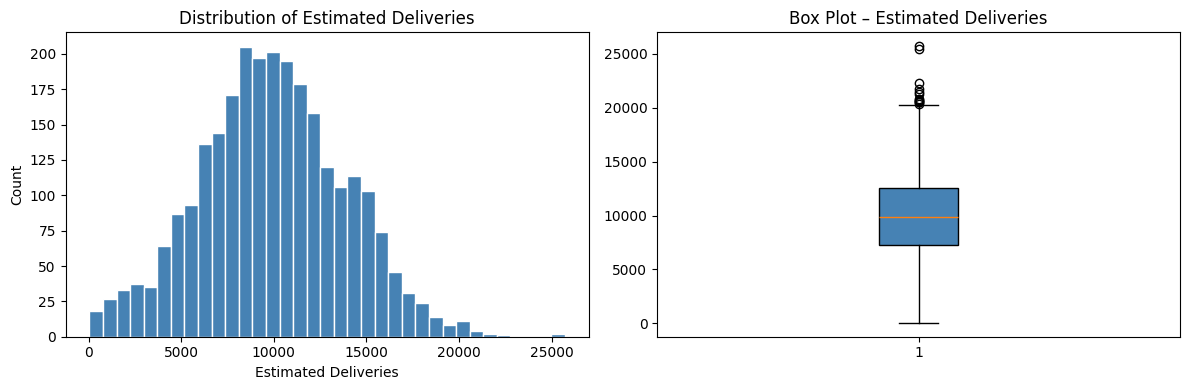

Skewness: 0.088
Kurtosis: -0.061


In [6]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["Estimated_Deliveries"], bins=35, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Estimated Deliveries")
axes[0].set_xlabel("Estimated Deliveries"); axes[0].set_ylabel("Count")

axes[1].boxplot(df["Estimated_Deliveries"], patch_artist=True,
                boxprops=dict(facecolor="steelblue"))
axes[1].set_title("Box Plot – Estimated Deliveries")
plt.tight_layout(); plt.show()

print(f"Skewness: {df['Estimated_Deliveries'].skew():.3f}")
print(f"Kurtosis: {df['Estimated_Deliveries'].kurt():.3f}")

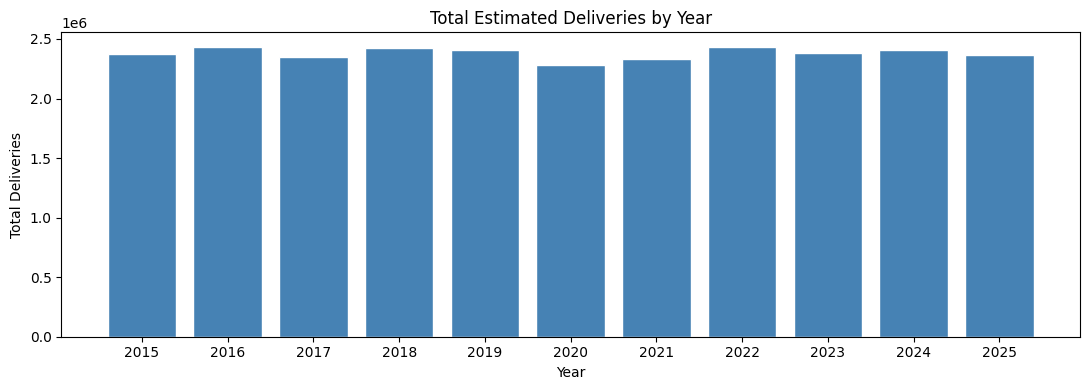

In [7]:
# Yearly delivery trend
yearly = df.groupby("Year")["Estimated_Deliveries"].sum()
plt.figure(figsize=(11, 4))
plt.bar(yearly.index, yearly.values, color="steelblue", edgecolor="white")
plt.title("Total Estimated Deliveries by Year")
plt.xlabel("Year"); plt.ylabel("Total Deliveries")
plt.xticks(yearly.index)
plt.tight_layout(); plt.show()

## 6. Encoding Techniques

In [8]:
df_enc = df.copy()
le = LabelEncoder()
for col in ["Region", "Model", "Source_Type"]:
    df_enc[col + "_enc"] = le.fit_transform(df_enc[col])
    df_enc.drop(columns=col, inplace=True)

print("Encoded columns added.")
df_enc.head()

Encoded columns added.


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_enc,Model_enc,Source_Type_enc
0,2023,5,17646,17922,92874.27,120,704,1863.42,12207,1,2,1
1,2015,2,3797,4164,62205.65,75,438,249.46,7640,0,3,2
2,2019,1,8411,9189,117887.32,82,480,605.59,14071,3,3,1
3,2021,2,6555,7311,89294.91,120,712,700.07,9333,3,1,2
4,2016,12,12374,13537,114846.78,120,661,1226.88,8722,2,4,0


## 7. Feature Engineering

In [9]:
df_fe = df_enc.copy()

# Cyclic encoding for Month (avoids treating Dec→Jan as large jump)
df_fe["Month_sin"] = np.sin(2 * np.pi * df_fe["Month"] / 12)
df_fe["Month_cos"] = np.cos(2 * np.pi * df_fe["Month"] / 12)

# Quarter
df_fe["Quarter"] = ((df_fe["Month"] - 1) // 3) + 1

# Price-per-range ratio
df_fe["Price_per_Range"] = df_fe["Avg_Price_USD"] / df_fe["Range_km"].replace(0, np.nan)

df_fe["CO2_per_Unit"] = df_fe["CO2_Saved_tons"] / df_fe["Production_Units"].replace(0, np.nan)

df_fe.dropna(inplace=True)
monthly = (df.groupby(["Year","Month"])["Estimated_Deliveries"]
             .sum().reset_index().sort_values(["Year","Month"]).reset_index(drop=True))

monthly["Lag_1"]      = monthly["Estimated_Deliveries"].shift(1)
monthly["Lag_3"]      = monthly["Estimated_Deliveries"].shift(3)
monthly["Roll_3_mean"]= monthly["Estimated_Deliveries"].rolling(3).mean()
monthly["Roll_6_std"] = monthly["Estimated_Deliveries"].rolling(6).std()
monthly.dropna(inplace=True)

print("Feature engineering done.")
print("Monthly time-series features:")
monthly[["Year","Month","Estimated_Deliveries","Lag_1","Lag_3","Roll_3_mean","Roll_6_std"]].head(8)

Feature engineering done.
Monthly time-series features:


,Year,Month,Estimated_Deliveries,Lag_1,Lag_3,Roll_3_mean,Roll_6_std
5,2015,6,198787,184264.0,184567.0,202891.333333,20382.010594
6,2015,7,177759,198787.0,225623.0,186936.666667,20872.120663
7,2015,8,214223,177759.0,184264.0,196923.000000,18996.690263
8,2015,9,188448,214223.0,198787.0,193476.666667,18526.999606
9,2015,10,221541,188448.0,177759.0,208070.666667,17355.818502
10,2015,11,211490,221541.0,214223.0,207159.666667,16750.572607
11,2015,12,220332,211490.0,188448.0,217787.666667,18163.158926
12,2016,1,191069,220332.0,221541.0,207630.333333,14526.858556


## 8. Feature Scaling & Sklearn Pipeline

In [10]:
TARGET   = "Estimated_Deliveries"
FEATURES = [c for c in df_fe.columns if c != TARGET]
X = df_fe[FEATURES]
y = df_fe[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (2112, 16) | Test: (528, 16)


## 9. Regression Models

In [11]:
def evaluate(name, model):
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    cv    = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
    return {
        "Model"   : name,
        "MAE"     : round(mean_absolute_error(y_test, preds)),
        "RMSE"    : round(np.sqrt(mean_squared_error(y_test, preds))),
        "R²"      : round(r2_score(y_test, preds), 4),
        "MAPE %"  : round(mean_absolute_percentage_error(y_test, preds) * 100, 2),
        "CV R² (mean)": round(cv.mean(), 4),
    }

results = pd.DataFrame([
    evaluate("Linear Regression",    LinearRegression()),
    evaluate("Ridge (L2)",           Ridge(alpha=1.0)),
    evaluate("Lasso (L1)",           Lasso(alpha=1.0)),
    evaluate("Random Forest",        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    evaluate("Gradient Boosting",    GradientBoostingRegressor(n_estimators=100, random_state=42)),
])
results.sort_values("R²", ascending=False).reset_index(drop=True)

,Model,MAE,RMSE,R²,MAPE %,CV R² (mean)
0,Lasso (L1),127,178,0.9979,1.92,0.9979
1,Linear Regression,128,179,0.9978,1.99,0.9979
2,Ridge (L2),129,180,0.9978,1.94,0.9979
3,Gradient Boosting,194,262,0.9954,2.03,0.9950
4,Random Forest,327,414,0.9885,3.44,0.9883


In [12]:
# Bias-Variance Tradeoff / Overfitting check
# Train R² vs Test R² gap reveals overfitting
for name, model in [
    ("Linear Regression", LinearRegression()),
    ("Random Forest",     RandomForestRegressor(n_estimators=100, random_state=42)),
]:
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    pipe.fit(X_train, y_train)
    train_r2 = r2_score(y_train, pipe.predict(X_train))
    test_r2  = r2_score(y_test,  pipe.predict(X_test))
    print(f"{name:25s}  Train R²={train_r2:.4f}  Test R²={test_r2:.4f}  Gap={train_r2-test_r2:.4f}")

Linear Regression          Train R²=0.9980  Test R²=0.9978  Gap=0.0001
Random Forest              Train R²=0.9984  Test R²=0.9885  Gap=0.0099


## 10. Hyperparameter Tuning

In [13]:
rf_pipe = Pipeline([("scaler", StandardScaler()),
                    ("rf", RandomForestRegressor(random_state=42, n_jobs=-1))])
param_grid = {
    "rf__n_estimators"     : [100, 200],
    "rf__max_depth"        : [None, 10, 20],
    "rf__min_samples_split": [2, 5],
}
grid_search = GridSearchCV(rf_pipe, param_grid, cv=5, scoring="r2", n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)

print("Best Params :", grid_search.best_params_)
print("Best CV R²  :", round(grid_search.best_score_, 4))

best_preds = grid_search.predict(X_test)
print(f"Test R²     : {r2_score(y_test, best_preds):.4f}")
print(f"Test RMSE   : {np.sqrt(mean_squared_error(y_test, best_preds)):.0f}")
print(f"Test MAE    : {mean_absolute_error(y_test, best_preds):.0f}")

Best Params : {'rf__max_depth': 20, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Best CV R²  : 0.9885
Test R²     : 0.9885
Test RMSE   : 414
Test MAE    : 326


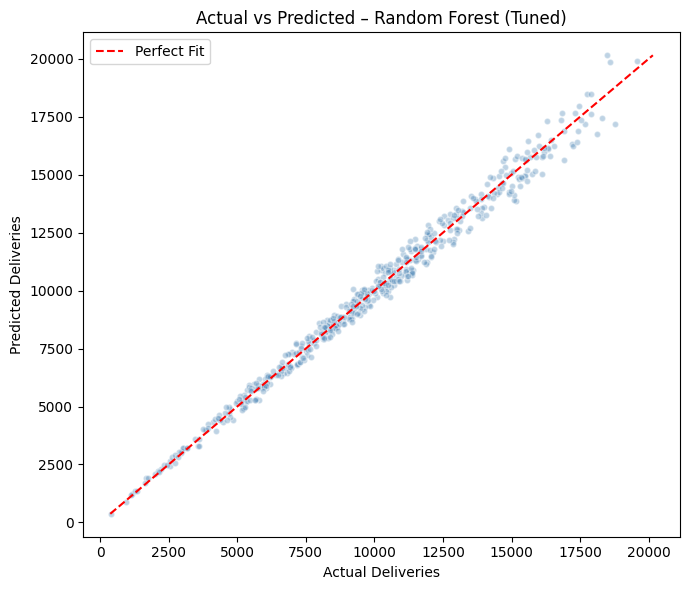

In [14]:
# Actual vs Predicted – tuned model
plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_preds, alpha=0.35, color="steelblue", edgecolors="white", s=20)
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, "r--", linewidth=1.5, label="Perfect Fit")
plt.xlabel("Actual Deliveries"); plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted – Random Forest (Tuned)")
plt.legend(); plt.tight_layout(); plt.show()

## 11. Time Series Forecasting


### 11.1 Prepare Monthly Series

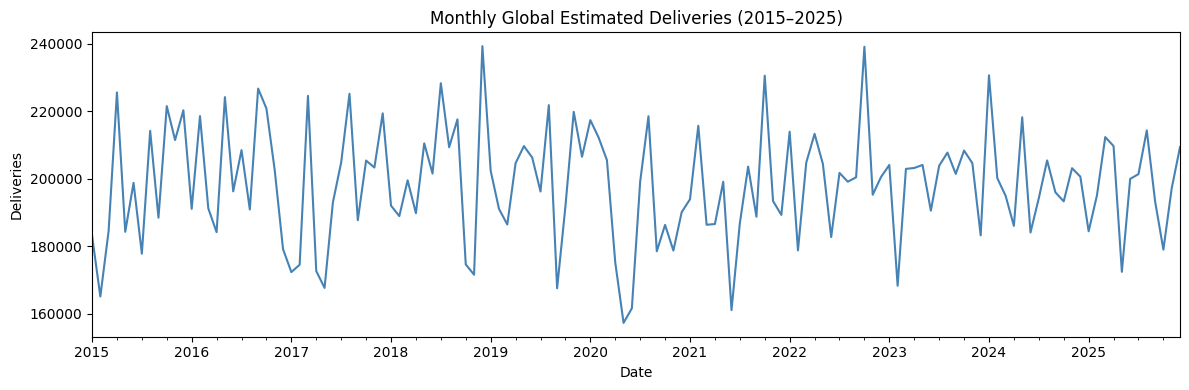

In [15]:
ts = (df.groupby(["Year","Month"])["Estimated_Deliveries"]
        .sum().reset_index()
        .assign(Date=lambda x: pd.to_datetime(
            x["Year"].astype(str) + "-" + x["Month"].astype(str).str.zfill(2)))
        .set_index("Date")["Estimated_Deliveries"]
        .sort_index())

ts.plot(title="Monthly Global Estimated Deliveries (2015–2025)",
        ylabel="Deliveries", color="steelblue", figsize=(12, 4))
plt.tight_layout(); plt.show()

### 11.2 Stationarity Test (ADF)

In [16]:
result = adfuller(ts)
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print(f"Critical (5%) : {result[4]['5%']:.4f}")
print("→ STATIONARY" if result[1] < 0.05 else "→ NON-STATIONARY – differencing recommended")

ADF Statistic : -8.8810
p-value       : 0.0000
Critical (5%) : -2.8840
→ STATIONARY


### 11.3 Chronological Split

In [17]:
ts_train = ts.iloc[:-12]   
ts_test  = ts.iloc[-12:]   

print(f"Train: {ts_train.index.min().date()} → {ts_train.index.max().date()} ({len(ts_train)} months)")
print(f"Test : {ts_test.index.min().date()}  → {ts_test.index.max().date()}  ({len(ts_test)} months)")

Train: 2015-01-01 → 2024-12-01 (120 months)
Test : 2025-01-01  → 2025-12-01  (12 months)


### 11.4 Holt-Winters Forecasting (Trend + Seasonality)

MAE : 10495
RMSE: 13872
R²  : -0.1626


C:\Users\Alpha\Desktop\Celebal_Technology\.celebal\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


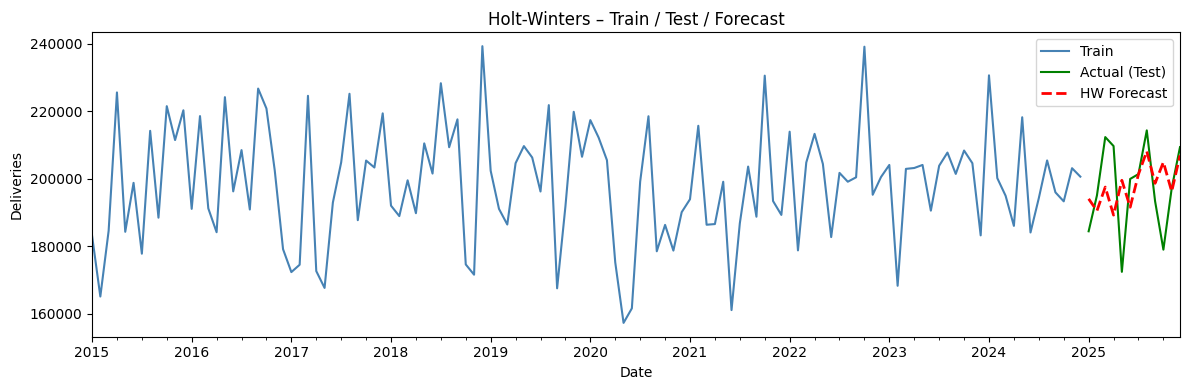

In [18]:
hw = ExponentialSmoothing(
    ts_train, trend="add", seasonal="add", seasonal_periods=12
).fit(optimized=True)
hw_pred = hw.forecast(12)
mae_ts  = mean_absolute_error(ts_test, hw_pred)
rmse_ts = np.sqrt(mean_squared_error(ts_test, hw_pred))
r2_ts   = r2_score(ts_test, hw_pred)
print(f"MAE : {mae_ts:.0f}")
print(f"RMSE: {rmse_ts:.0f}")
print(f"R²  : {r2_ts:.4f}")

plt.figure(figsize=(12, 4))
ts_train.plot(label="Train",           color="steelblue", linewidth=1.5)
ts_test.plot( label="Actual (Test)",   color="green",     linewidth=1.5)
hw_pred.plot( label="HW Forecast",     color="red",       linewidth=2, linestyle="--")
plt.title("Holt-Winters – Train / Test / Forecast")
plt.ylabel("Deliveries"); plt.legend(); plt.tight_layout(); plt.show()

### 11.5 2026 Forecast Table

In [19]:
hw_full   = ExponentialSmoothing(
    ts, trend="add", seasonal="add", seasonal_periods=12
).fit(optimized=True)
future = hw_full.forecast(12)
future.index = pd.date_range(
    start=ts.index[-1] + pd.DateOffset(months=1), periods=12, freq="MS")

forecast_df = future.round(0).rename("Forecast_Deliveries").to_frame()
forecast_df.index.name = "Month"
print("2026 Monthly Delivery Forecast")
forecast_df

2026 Monthly Delivery Forecast


C:\Users\Alpha\Desktop\Celebal_Technology\.celebal\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,Forecast_Deliveries
Month,
2026-01-01,192502.0
2026-02-01,190434.0
2026-03-01,198070.0
2026-04-01,189793.0
2026-05-01,197736.0
2026-06-01,192219.0
2026-07-01,201205.0
2026-08-01,208205.0
2026-09-01,198374.0
